# Notebook 7 - Battery Sentinel Data and Regime Design

This notebook opens the applied branch of the project. The original six notebooks establish the three noise geometries on a controlled diffusion study. Battery Sentinel reuses that idea in a practical setting: EV battery monitoring under three operational uncertainty regimes.


## Link with the original research

The original project established three forward-noise families:

- Gaussian
- Uniform
- Laplace

Battery Sentinel translates them into three battery-monitoring regimes:

- **Gaussian**: normal operating variation and background sensor noise
- **Uniform**: bounded telemetry degradation and coarse measurement resolution
- **Laplace**: impulsive anomalies, spikes, and abrupt dangerous deviations

The purpose is no longer generation quality. The purpose is to decide whether a suspicious battery trace reflects ordinary behavior, poor telemetry, or a genuine fault-like event.


In [1]:
!pip install -q matplotlib pandas numpy seaborn


In [2]:
from pathlib import Path
import json
import math
import os
import random
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

IN_COLAB = False
try:
    from google.colab import drive
    drive.mount('/content/drive')
    IN_COLAB = True
except Exception:
    drive = None

FOUNDATION_DRIVE_DIR = '/content/drive/MyDrive/diffusion_noise_project'
FOUNDATION_DIR = '/content/foundation_diffusion_noise_project'
BATTERY_ROOT = '/content/drive/MyDrive/battery_sentinel'

if IN_COLAB:
    if not os.path.exists(FOUNDATION_DRIVE_DIR):
        raise FileNotFoundError(f'Foundation artifacts not found in Drive: {FOUNDATION_DRIVE_DIR}')
    if os.path.exists(FOUNDATION_DIR):
        shutil.rmtree(FOUNDATION_DIR)
    shutil.copytree(FOUNDATION_DRIVE_DIR, FOUNDATION_DIR)
else:
    FOUNDATION_DIR = str((Path.cwd() / 'diffusion_noise_project' / 'diffusion_noise_project').resolve())
    BATTERY_ROOT = str((Path.cwd() / 'diffusion_noise_project' / 'diffusion_noise_project' / 'battery_sentinel').resolve())

DATA_DIR = os.path.join(BATTERY_ROOT, 'data')
LOG_DIR = os.path.join(BATTERY_ROOT, 'logs')
FIGURE_DIR = os.path.join(BATTERY_ROOT, 'figures')
MODEL_DIR = os.path.join(BATTERY_ROOT, 'models')
for path in [BATTERY_ROOT, DATA_DIR, LOG_DIR, FIGURE_DIR, MODEL_DIR]:
    os.makedirs(path, exist_ok=True)

print('Foundation root:', FOUNDATION_DIR)
print('Battery Sentinel root:', BATTERY_ROOT)



Mounted at /content/drive
Foundation root: /content/foundation_diffusion_noise_project
Battery Sentinel root: /content/drive/MyDrive/battery_sentinel


In [4]:
with open(os.path.join(FOUNDATION_DIR, 'config.json'), 'r', encoding='utf-8') as handle:
    BASE_CONFIG = json.load(handle)

SIM_CONFIG = {
    'seed': int(BASE_CONFIG.get('seed', 42)),
    'num_sessions_per_regime': 480,
    'sequence_length': 128,
    'dt_hours': 1.0 / 60.0,
    'feature_names': ['soc', 'voltage', 'current', 'temperature'],
    'regimes': ['gaussian', 'uniform', 'laplace'],
    'quant_steps': {'soc': 0.01, 'voltage': 0.025, 'current': 1.0, 'temperature': 0.5},
    'gaussian_noise_std': {'soc': 0.002, 'voltage': 0.010, 'current': 0.35, 'temperature': 0.10},
    'laplace_noise_scale': {'soc': 0.004, 'voltage': 0.018, 'current': 0.60, 'temperature': 0.18},
}
SIM_CONFIG


{'seed': 42,
 'num_sessions_per_regime': 480,
 'sequence_length': 128,
 'dt_hours': 0.016666666666666666,
 'feature_names': ['soc', 'voltage', 'current', 'temperature'],
 'regimes': ['gaussian', 'uniform', 'laplace'],
 'quant_steps': {'soc': 0.01,
  'voltage': 0.025,
  'current': 1.0,
  'temperature': 0.5},
 'gaussian_noise_std': {'soc': 0.002,
  'voltage': 0.01,
  'current': 0.35,
  'temperature': 0.1},
 'laplace_noise_scale': {'soc': 0.004,
  'voltage': 0.018,
  'current': 0.6,
  'temperature': 0.18}}

In [5]:
def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)

def ocv_curve(soc):
    soc = np.clip(soc, 0.0, 1.0)
    return 3.0 + 1.12 * soc + 0.06 * np.tanh((soc - 0.5) * 4.5) + 0.02 * np.sin(np.pi * soc)

def quantize(values, step):
    return np.round(values / step) * step

def piecewise_charge_profile(length, max_current):
    profile = np.zeros(length, dtype=np.float32)
    warmup = max(8, length // 8)
    taper_start = int(length * np.random.uniform(0.55, 0.72))
    for t in range(length):
        if t < warmup:
            frac = (t + 1) / warmup
            profile[t] = max_current * frac
        elif t < taper_start:
            profile[t] = max_current * np.random.uniform(0.96, 1.03)
        else:
            decay = np.exp(-(t - taper_start) / max(8.0, length * 0.12))
            profile[t] = max_current * (0.25 + 0.75 * decay)
    for _ in range(np.random.randint(1, 4)):
        start = np.random.randint(0, length - 6)
        width = np.random.randint(2, 6)
        profile[start:start+width] *= np.random.uniform(0.1, 0.4)
    return profile.astype(np.float32)

def simulate_battery_session(regime: str, length: int, dt_hours: float):
    capacity_ah = np.random.uniform(48.0, 72.0)
    health_factor = np.random.uniform(0.92, 1.03)
    ohmic_resistance = np.random.uniform(0.010, 0.022) * (1.0 + 0.12 * (1.0 - health_factor))
    ambient_temp = np.random.uniform(18.0, 32.0)
    max_current = np.random.uniform(35.0, 85.0)
    eta_charge = np.random.uniform(0.95, 0.99)

    soc = np.zeros(length, dtype=np.float32)
    voltage = np.zeros(length, dtype=np.float32)
    current = piecewise_charge_profile(length, max_current)
    temperature = np.zeros(length, dtype=np.float32)
    rc_state = 0.0

    soc[0] = np.random.uniform(0.12, 0.45)
    temperature[0] = ambient_temp + np.random.uniform(-1.5, 1.5)

    shock_mask = np.zeros(length, dtype=np.float32)
    shock_signal = np.zeros(length, dtype=np.float32)
    if regime == 'laplace':
        shock_count = np.random.randint(2, 5)
        for _ in range(shock_count):
            center = np.random.randint(10, length - 10)
            amplitude = np.random.uniform(0.04, 0.11)
            duration = np.random.randint(4, 12)
            for offset in range(duration):
                idx = center + offset
                if idx >= length:
                    break
                decay = np.exp(-offset / max(duration / 3.0, 1.0))
                shock_signal[idx] += amplitude * decay
                shock_mask[idx] = 1.0

    for t in range(length):
        if t > 0:
            soc[t] = np.clip(soc[t-1] + eta_charge * current[t-1] * dt_hours / capacity_ah, 0.0, 1.0)
            temperature[t] = temperature[t-1] + 0.025 * abs(current[t-1]) * ohmic_resistance - 0.050 * (temperature[t-1] - ambient_temp) + np.random.normal(0.0, 0.03)
        rc_state = 0.90 * rc_state + 0.0018 * current[t]
        voltage[t] = ocv_curve(soc[t]) + current[t] * ohmic_resistance + rc_state

    true_series = np.stack([soc, voltage, current, temperature], axis=-1).astype(np.float32)
    observed = true_series.copy()

    gstd = SIM_CONFIG['gaussian_noise_std']
    observed[:, 0] += np.random.normal(0.0, gstd['soc'], length)
    observed[:, 1] += np.random.normal(0.0, gstd['voltage'], length)
    observed[:, 2] += np.random.normal(0.0, gstd['current'], length)
    observed[:, 3] += np.random.normal(0.0, gstd['temperature'], length)

    if regime == 'uniform':
        q = SIM_CONFIG['quant_steps']
        observed[:, 0] = quantize(observed[:, 0], q['soc'])
        observed[:, 1] = quantize(observed[:, 1], q['voltage'])
        observed[:, 2] = quantize(observed[:, 2], q['current'])
        observed[:, 3] = quantize(observed[:, 3], q['temperature'])
    elif regime == 'laplace':
        lscale = SIM_CONFIG['laplace_noise_scale']
        observed[:, 0] += np.random.laplace(0.0, lscale['soc'], length)
        observed[:, 1] += np.random.laplace(0.0, lscale['voltage'], length) + shock_signal
        observed[:, 2] += np.random.laplace(0.0, lscale['current'], length) + 12.0 * shock_mask * np.random.choice([-1.0, 1.0], size=length)
        observed[:, 3] += np.random.laplace(0.0, lscale['temperature'], length) + 2.8 * shock_signal / max(shock_signal.max(), 1e-6)

    observed[:, 0] = np.clip(observed[:, 0], 0.0, 1.0)
    metadata = {
        'capacity_ah': float(capacity_ah),
        'health_factor': float(health_factor),
        'ohmic_resistance': float(ohmic_resistance),
        'ambient_temp': float(ambient_temp),
        'max_current': float(max_current),
        'shock_steps': int(shock_mask.sum()),
    }
    return true_series, observed.astype(np.float32), shock_mask.astype(np.float32), metadata


In [6]:
set_seed(SIM_CONFIG['seed'])
all_true, all_observed, all_regimes, all_shocks, metadata_rows = [], [], [], [], []

for regime in SIM_CONFIG['regimes']:
    for session_idx in range(SIM_CONFIG['num_sessions_per_regime']):
        true_series, observed_series, shock_mask, meta = simulate_battery_session(regime=regime, length=SIM_CONFIG['sequence_length'], dt_hours=SIM_CONFIG['dt_hours'])
        all_true.append(true_series)
        all_observed.append(observed_series)
        all_regimes.append(regime)
        all_shocks.append(shock_mask)
        metadata_rows.append({'session_id': len(all_regimes) - 1, 'regime': regime, **meta})

true_array = np.stack(all_true).astype(np.float32)
observed_array = np.stack(all_observed).astype(np.float32)
shock_array = np.stack(all_shocks).astype(np.float32)
regime_array = np.array(all_regimes)
metadata_df = pd.DataFrame(metadata_rows)

rng = np.random.default_rng(SIM_CONFIG['seed'])
indices = np.arange(len(regime_array))
rng.shuffle(indices)
train_cut = int(0.70 * len(indices))
val_cut = int(0.85 * len(indices))
splits = {'train': indices[:train_cut], 'val': indices[train_cut:val_cut], 'test': indices[val_cut:]}

np.savez_compressed(
    os.path.join(DATA_DIR, 'battery_sentinel_dataset.npz'),
    true_series=true_array,
    observed_series=observed_array,
    shock_mask=shock_array,
    regime_labels=regime_array,
    train_indices=splits['train'],
    val_indices=splits['val'],
    test_indices=splits['test'],
)
metadata_df.to_csv(os.path.join(DATA_DIR, 'battery_sentinel_metadata.csv'), index=False)
summary = {
    'num_sessions': int(len(regime_array)),
    'sequence_length': int(SIM_CONFIG['sequence_length']),
    'feature_names': SIM_CONFIG['feature_names'],
    'split_sizes': {key: int(len(value)) for key, value in splits.items()},
    'regime_counts': metadata_df['regime'].value_counts().to_dict(),
    'average_shock_steps': float(metadata_df['shock_steps'].mean()),
}
with open(os.path.join(LOG_DIR, 'simulation_summary.json'), 'w', encoding='utf-8') as handle:
    json.dump(summary, handle, indent=2)
summary


{'num_sessions': 1440,
 'sequence_length': 128,
 'feature_names': ['soc', 'voltage', 'current', 'temperature'],
 'split_sizes': {'train': 1007, 'val': 217, 'test': 216},
 'regime_counts': {'gaussian': 480, 'uniform': 480, 'laplace': 480},
 'average_shock_steps': 6.817361111111111}

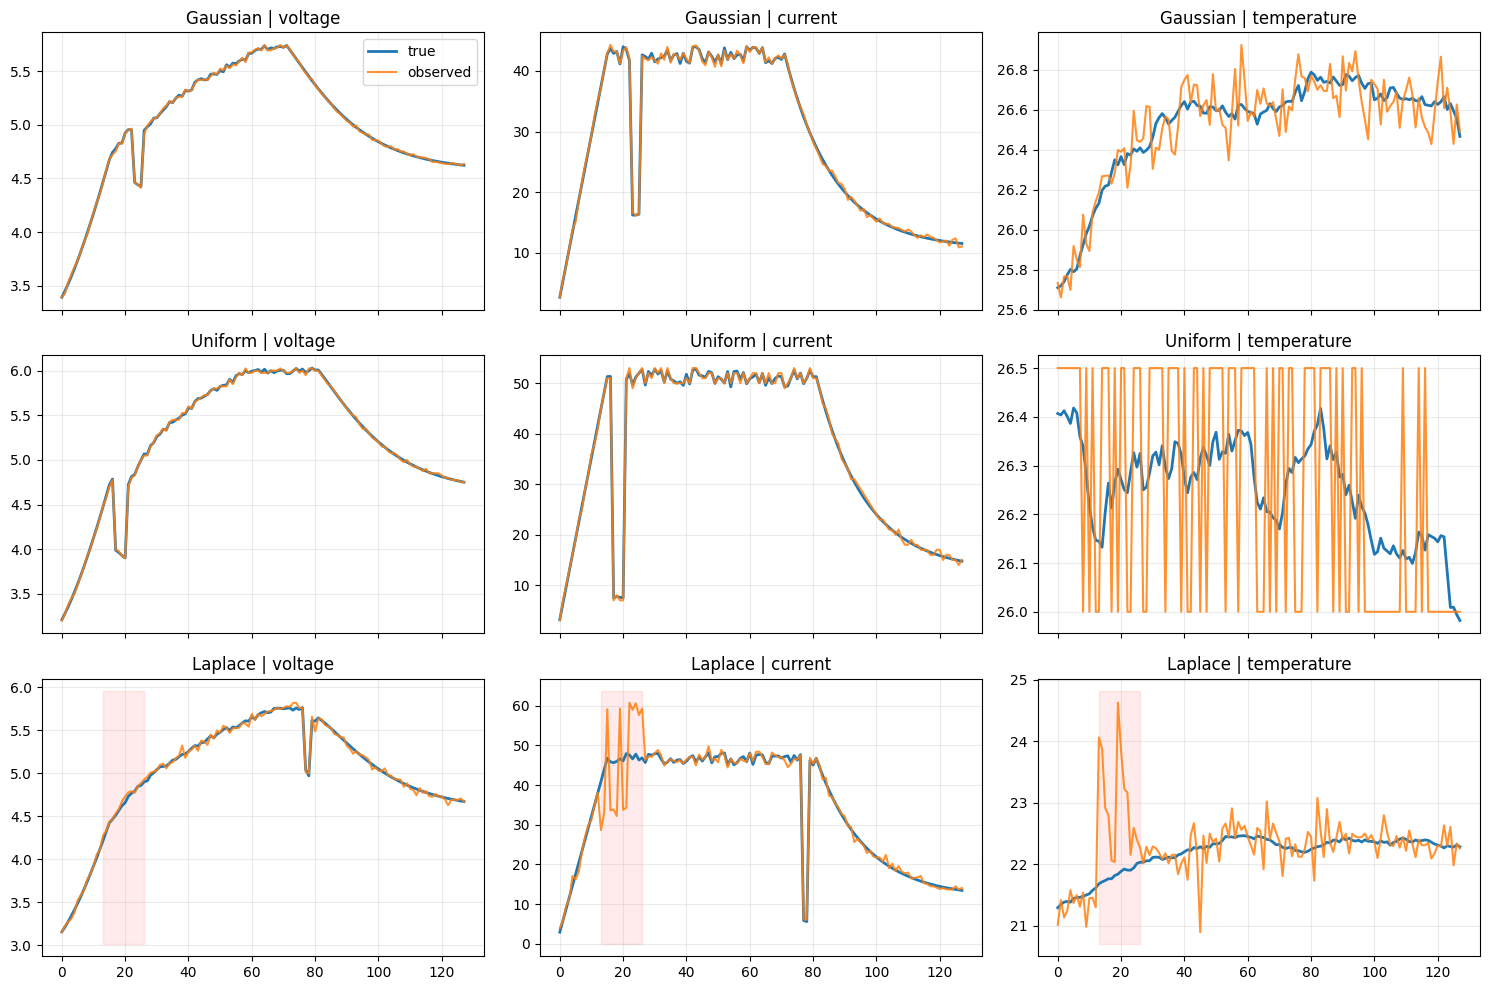

Saved: /content/drive/MyDrive/battery_sentinel/figures/battery_regime_examples.png


In [7]:
fig, axes = plt.subplots(3, 3, figsize=(15, 10), sharex=True)
plot_features = [('voltage', 1), ('current', 2), ('temperature', 3)]
for row_idx, regime in enumerate(SIM_CONFIG['regimes']):
    session_idx = np.where(regime_array == regime)[0][0]
    true_series = true_array[session_idx]
    observed_series = observed_array[session_idx]
    shock_mask = shock_array[session_idx]
    for col_idx, (name, idx) in enumerate(plot_features):
        ax = axes[row_idx, col_idx]
        ax.plot(true_series[:, idx], label='true', linewidth=2)
        ax.plot(observed_series[:, idx], label='observed', linewidth=1.5, alpha=0.85)
        if regime == 'laplace' and shock_mask.sum() > 0:
            lo, hi = ax.get_ylim()
            ax.fill_between(np.arange(len(shock_mask)), lo, hi, where=shock_mask > 0, alpha=0.08, color='red')
        ax.set_title(f'{regime.title()} | {name}')
        ax.grid(alpha=0.25)
        if row_idx == 0 and col_idx == 0:
            ax.legend(loc='best')
fig.tight_layout()
example_path = os.path.join(FIGURE_DIR, 'battery_regime_examples.png')
fig.savefig(example_path, dpi=200, bbox_inches='tight')
plt.show()
print('Saved:', example_path)


In [8]:
summary_table = metadata_df.groupby('regime')[['capacity_ah', 'ohmic_resistance', 'max_current', 'shock_steps']].agg(['mean', 'std']).round(3)
display(summary_table)


capacity_ah        ohmic_resistance        max_current          \
                mean    std             mean    std        mean     std   
regime                                                                    
gaussian      60.832  6.834            0.016  0.003      59.508  15.010   
laplace       60.416  6.734            0.016  0.003      59.591  15.069   
uniform       60.078  6.859            0.016  0.003      59.713  14.627   

         shock_steps         
                mean    std  
regime                       
gaussian       0.000  0.000  
laplace       20.452  6.748  
uniform        0.000  0.000

## Expected result

After running this notebook, you should have a structured Battery Sentinel dataset saved under:

- `battery_sentinel/data/battery_sentinel_dataset.npz`
- `battery_sentinel/data/battery_sentinel_metadata.csv`
- `battery_sentinel/logs/simulation_summary.json`
- `battery_sentinel/figures/battery_regime_examples.png`

This dataset is the bridge from the original diffusion-noise study to the applied battery-monitoring branch.
